# 04 - Missing Value Analysis

## Context
In fraud detection datasets, missingness is rarely random. The IEEE-CIS data exhibits complex patterns where missing values often correlate with transaction characteristics and fraud outcomes. Understanding these patterns is essential before choosing imputation strategies.

## Objective
- Quantify missingness across all feature groups.
- Analyze the correlation between missingness and fraud outcomes.
- Identify feature-level and row-level missingness patterns.
- Develop imputation strategy recommendations.

In [1]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")

DATA_DIR = Path("../data/interim")
TRAIN_PATH = DATA_DIR / "train_merged.parquet"
METADATA_DIR = Path("../data/metadata")

In [2]:
train = pd.read_parquet(TRAIN_PATH)
print(f'Data loaded: {train.shape}')

Data loaded: (590540, 434)


In [3]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).sort_values(ascending=False)
cols_missing = missing_pct[missing_pct > 0]

print('Missing Overview:')
print(f'   Total Columns: {len(train.columns)}')
print(f'   Columns with missing: {len(cols_missing)} ({len(cols_missing)/len(train.columns)*100:.1f}%)')
print(f'   0% missing: {(missing_pct==0).sum()} columns')
print(f'   1-10% missing: {((missing_pct>0)&(missing_pct<=10)).sum()} columns')
print(f'   10-50% missing: {((missing_pct>10)&(missing_pct<=50)).sum()} columns')
print(f'   50-90% missing: {((missing_pct>50)&(missing_pct<=90)).sum()} columns')
print(f'   >90% missing: {(missing_pct>90).sum()} columns')

Missing Overview:
   Total Columns: 434
   Columns with missing: 414 (95.4%)
   0% missing: 20 columns
   1-10% missing: 92 columns
   10-50% missing: 108 columns
   50-90% missing: 202 columns
   >90% missing: 12 columns


### Insight: Missingness Distribution

- Mayoritas columns punya missing values — wajar di fraud dataset
- Ada tiered distribution: low, medium, high missingness
- Columns dengan >90% missing mungkin kandidat untuk di-drop

In [4]:
col_group = {
    "Transaction": ("TransactionID", "TransactionDT", "TransactionAmt", "ProductCD"),
    "Card": tuple(f"card{i}" for i in range(1, 7)),
    "Address": ("addr1", "addr2", "dist1", "dist2"),
    "Email": ("P_emaildomain", "R_emaildomain"),
    "Count": tuple(f"C{i}" for i in range(1, 15)),
    "TimeDelta": tuple(f"D{i}" for i in range(1, 16)),
    "Match": tuple(f"M{i}" for i in range(1, 10)),
    "Vesta": tuple(f"V{i}" for i in range(1, 340)),
    "Identity": tuple(f"id_{str(i).zfill(2)}" for i in range(1, 39)),
    "Device": ("DeviceType", "DeviceInfo"),
}

print('Average Missing Rate by Feature Group:')
for name, cols in col_group.items():
    valid_cols = [c for c in cols if c in train.columns]
    if valid_cols:
        total_missing = train[valid_cols].isna().sum().sum()
        total_cells = train[valid_cols].size
        avg_missing = (total_missing / total_cells) * 100
        print(f'   {name}: {avg_missing:.1f}%')

Average Missing Rate by Feature Group:
   Transaction: 0.0%
   Card: 0.5%
   Address: 43.9%
   Email: 46.4%
   Count: 0.0%
   TimeDelta: 58.2%
   Match: 49.9%
   Vesta: 43.0%
   Identity: 84.8%
   Device: 78.0%


### Insight: Missingness by Feature Group

- **Core features** (Transaction, Card, Count): minimal missing — selalu terkumpul
- **Identity features**: high missing (~75%) — cuma terkumpul untuk subset transaksi
- **V (Vesta) features**: variable missing dengan block-wise patterns

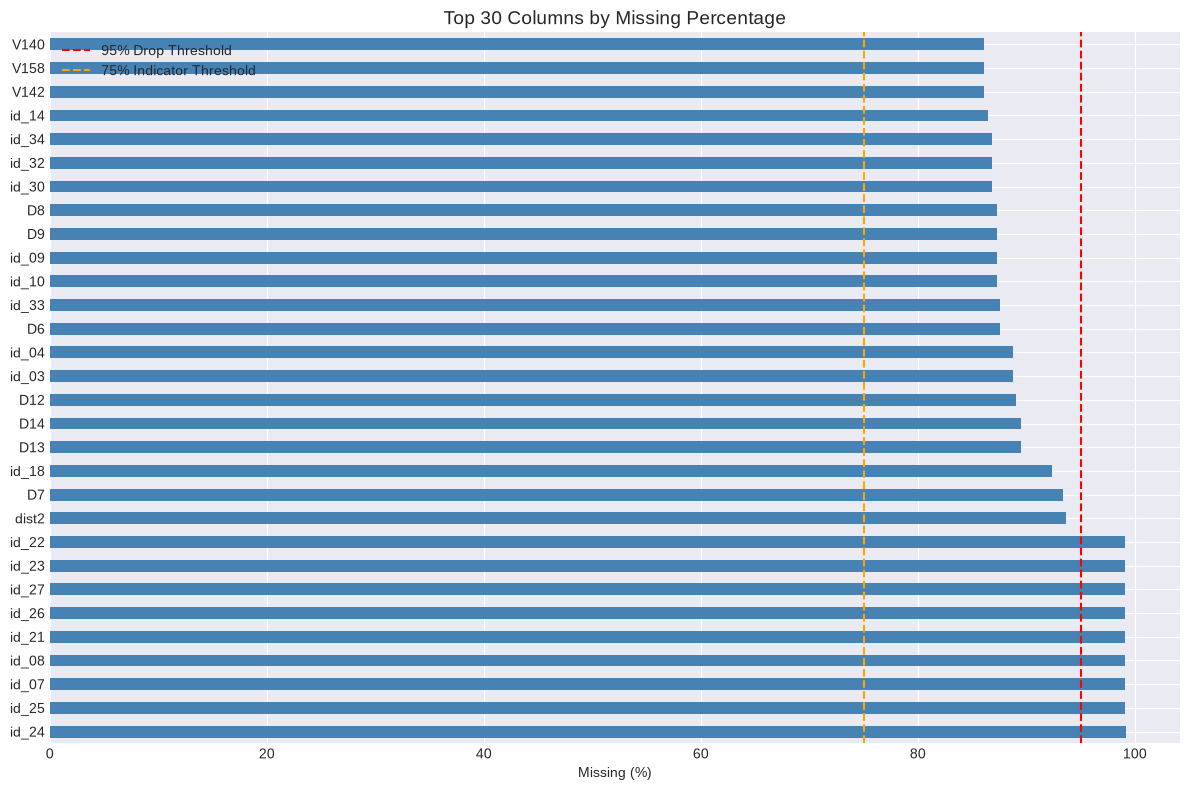

In [5]:
top_missing = missing_pct.head(30)

fig, ax = plt.subplots(figsize=(12, 8))
top_missing.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 30 Columns by Missing Percentage', fontsize=14)
ax.set_xlabel('Missing (%)')
ax.axvline(x=95, color='red', linestyle='--', label='95% Drop Threshold')
ax.axvline(x=75, color='orange', linestyle='--', label='75% Indicator Threshold')
ax.legend()
plt.tight_layout()
plt.show()

### Insight: Top Missing Columns

- **Identity features** mendominasi kolom dengan missing tertinggi (id_XX, DeviceInfo, DeviceType)
- Banyak kolom cluster di ~75-76% missing (identity coverage threshold)
- Columns di atas 75% perlu dievaluasi: keep only jika punya strong fraud signal

In [6]:
results = []
for col in cols_missing.index[:30]:
    mask_missing = train[col].isnull()
    fraud_missing = train.loc[mask_missing, 'isFraud'].mean() * 100
    fraud_present = train.loc[~mask_missing, 'isFraud'].mean() * 100

    results.append({
        'column': col,
        'missing_pct': missing_pct[col],
        'fraud_missing': fraud_missing,
        'fraud_present': fraud_present,
        'fraud_diff': fraud_missing - fraud_present
    })

missing_fraud_df = pd.DataFrame(results)
print('Fraud Rate: Missing vs Present')
print(missing_fraud_df.sort_values('fraud_diff', ascending=False).head(15).to_string(index=False))

Fraud Rate: Missing vs Present
column  missing_pct  fraud_missing  fraud_present  fraud_diff
 id_30    86.865411       3.357084       4.437568   -1.080485
 id_32    86.861855       3.355467       4.447967   -1.092501
  V140    86.123717       3.345098       4.454207   -1.109109
  V158    86.123717       3.345098       4.454207   -1.109109
  V142    86.123717       3.345098       4.454207   -1.109109
 id_14    86.445626       3.346549       4.471291   -1.124742
 id_34    86.824771       3.350269       4.479147   -1.128878
 id_33    87.589494       3.344604       4.588683   -1.244079
 id_25    99.130965       3.458443       8.125487   -4.667044
 id_26    99.125715       3.457259       8.231648   -4.774389
 id_27    99.124699       3.457124       8.241439   -4.784316
 id_23    99.124699       3.457124       8.241439   -4.784316
 id_22    99.124699       3.457124       8.241439   -4.784316
 id_21    99.126393       3.457065       8.257414   -4.800350
 id_07    99.127070       3.457041     

### Insight: Missingness Predicts Fraud

- Beberapa features menunjukkan perbedaan fraud rate antara missing vs present values
- **Action**: untuk feature dengan >10% missing yang menunjukkan korelasi, bikin binary `{feature}_missing` indicator sebelum imputasi

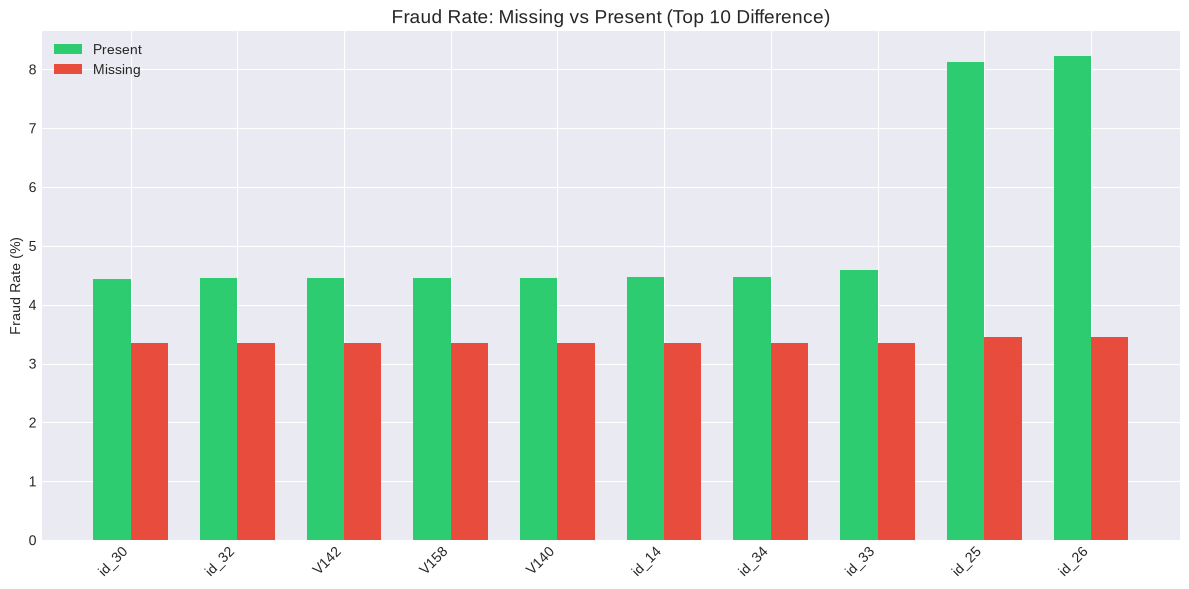

In [7]:
top_diff = missing_fraud_df.nlargest(10, 'fraud_diff')

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top_diff))
width = 0.35

ax.bar([i - width/2 for i in x], top_diff['fraud_present'], width, label='Present', color='#2ecc71')
ax.bar([i + width/2 for i in x], top_diff['fraud_missing'], width, label='Missing', color='#e74c3c')

ax.set_xticks(list(x))
ax.set_xticklabels(top_diff['column'], rotation=45, ha='right')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate: Missing vs Present (Top 10 Difference)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### Insight: Missing vs Present Fraud Gap

- Bar chart ngasih visual fraud rate gap antara missing (merah) vs present (hijau)
- Columns dengan gap > besar lebih valuable sebagai missingness indicators

In [8]:
def get_imputation_strategy(missing_pct, dtype):
    """Return imputation strategy based on missing percentage and dtype."""
    if missing_pct == 0:
        return "None needed"
    if missing_pct > 95:
        return "Drop column"
    if missing_pct > 75:
        return "Indicator only"
    is_numeric = pd.api.types.is_numeric_dtype(dtype)
    if missing_pct > 10:
        return "Median + Indicator" if is_numeric else "Mode + Indicator"
    return "Median" if is_numeric else "Mode"

recommendations = []
for col in train.columns:
    pct = missing_pct.get(col, 0)
    strategy = get_imputation_strategy(pct, train[col].dtype)
    recommendations.append({
        "column": col,
        "missing_pct": pct,
        "dtype": str(train[col].dtype),
        "strategy": strategy
    })

rec_df = pd.DataFrame(recommendations)
print("Imputation Strategy Summary:")
print(rec_df["strategy"].value_counts().to_string())

Imputation Strategy Summary:
strategy
Indicator only        199
Median + Indicator    104
Median                 90
None needed            20
Mode + Indicator       10
Drop column             9
Mode                    2


### Insight: Imputation Strategy Distribution

- **None needed**: complete columns
- **Median / Median + Indicator**: numeric columns with varying missingness
- **Mode + Indicator**: categorical columns
- **Indicator only**: sangat high missingness — imputing values adds noise
- **Drop column**: >95% missing tanpa signal

**Important**: imputation statistics (median, mode) harus di fit di training data only untuk prevent leakage.

In [9]:
METADATA_DIR.mkdir(parents=True, exist_ok=True)
rec_df.to_csv(METADATA_DIR / "missing_value_report.csv", index=False)

print(f"Saved to {METADATA_DIR / 'missing_value_report.csv'}")
print()
print("Sample:")
print(rec_df.head(10).to_string(index=False))

Saved to ../data/metadata/missing_value_report.csv

Sample:
        column  missing_pct    dtype    strategy
 TransactionID     0.000000    int32 None needed
       isFraud     0.000000     int8 None needed
 TransactionDT     0.000000    int32 None needed
TransactionAmt     0.000000  float32 None needed
     ProductCD     0.000000 category None needed
         card1     0.000000    int16 None needed
         card2     1.512683  float32      Median
         card3     0.265012  float32      Median
         card4     0.267044 category        Mode
         card5     0.721204  float32      Median
